# Lecture: Learning the Gaussian distribution



Run the following cell only if you are working with google colab to copy the required .py file in the root directory. If you are working locally just ignore this cell!

In [ ]:
!git clone https://github.com/Fjoelsak/AIBIP.git
!cp AIBIP/06-Generative_Image_Models/Gaussian1D.py ./

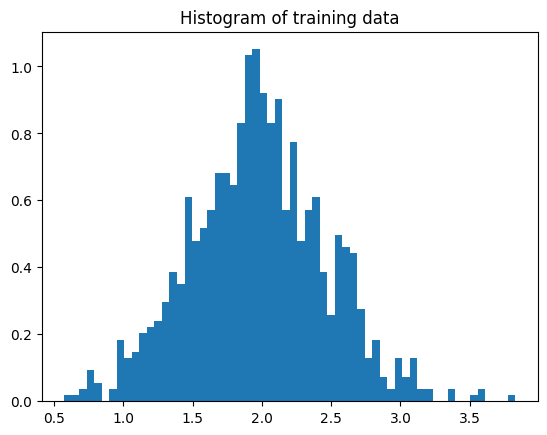

In [20]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

from Gaussian1D import Gaussian1D

# Generate synthetic data
true_mu = 2.0
true_sigma = 0.5
data = torch.randn(1000) * true_sigma + true_mu

plt.hist(data, density=True, bins=60)
plt.title('Histogram of training data')
plt.show()

In [21]:
model = Gaussian1D()
optimizer = optim.Adam(model.parameters(), lr=0.05)

# Training
loss_history = []
for i in range(500):
    # reset gradients
    optimizer.zero_grad()
    # define loss as negative log likelihood
    loss = -model.log_likelihood(data).mean()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

print("Learned mu:", model.mu.item())
print("Learned sigma:", torch.exp(0.5 * model.log_var).item())

Learned mu: 1.9786094427108765
Learned sigma: 0.48696303367614746


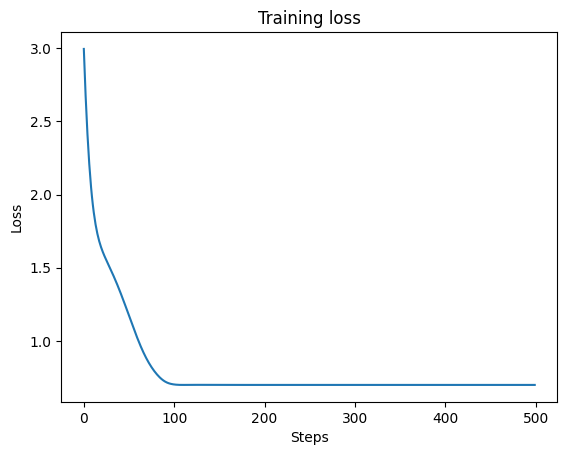

In [22]:
plt.plot(loss_history)
plt.title('Training loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.show()

In [23]:
import math

learned_mu = model.mu.item()
learned_sigma = torch.exp(0.5 * model.log_var).item()

# Fine grid
x = torch.linspace(-1, 5, 1000)

# True density
true_density = (1 / (true_sigma * math.sqrt(2 * math.pi))) * \
               torch.exp(-(x - true_mu)**2 / (2 * true_sigma**2))

# Learned density
learned_density = (1 / (learned_sigma * math.sqrt(2 * math.pi))) * \
                  torch.exp(-(x - learned_mu)**2 / (2 * learned_sigma**2))

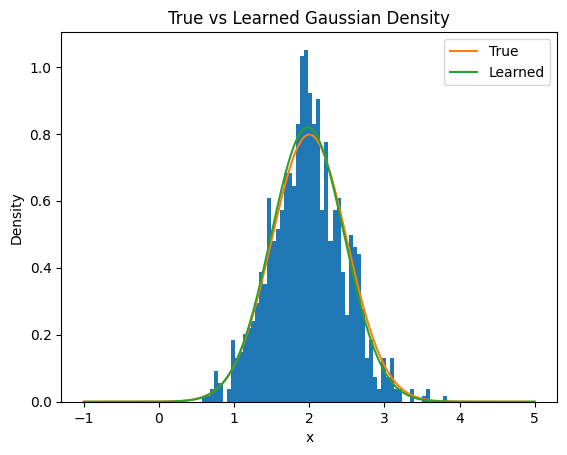

In [25]:
plt.figure()
plt.hist(data.numpy(), bins=60, density=True)
plt.plot(x.numpy(), true_density.numpy())
plt.plot(x.numpy(), learned_density.detach().numpy())
plt.title("True vs Learned Gaussian Density")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend(["True", "Learned"])
plt.show()